
# Sharpen / Blur Testing Notebook

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import csv


## Load Selected Frames

In [2]:
import cv2, os, glob
import numpy as np

INPUT_DIR = "../data/frames/selected"

def lap_var(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

paths = []

for root, dirs, files in os.walk(INPUT_DIR):
    for f in files:
        if f.lower().endswith((".jpg",".png",".jpeg")):
            paths.append(os.path.join(root,f))

scores = []

for p in paths:

    img = cv2.imread(p,0)

    if img is None:
        continue

    scores.append((p, lap_var(img)))

scores.sort(key=lambda x: x[1])

test_paths = [
    scores[0][0],
    scores[len(scores)//2][0],
    scores[-1][0]
]

images = []
names = []

for p in test_paths:

    img = cv2.imread(p,0)

    images.append(img)
    names.append(os.path.basename(p))

print("Selected test frames:")
for p in test_paths:
    print(os.path.basename(p))

print("Total test frames:", len(images))

Selected test frames:
transverse_cracking_02_frame_70.jpg
edge_cracking_03_frame_520.jpg
transverse_cracking_03_frame_0.jpg
Total test frames: 3


## Sharpen Methods

In [3]:

def unsharp(img, k, amount):
    blur = cv2.GaussianBlur(img,(k,k),0)
    sharp = cv2.addWeighted(img,1+amount,blur,-amount,0)
    return sharp

def laplacian_sharp(img, a):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    sharp = img + a*lap
    sharp = np.clip(sharp,0,255).astype(np.uint8)
    return sharp


## Sharpness Evaluation (LapVar)

In [4]:

print("===== SHARPNESS TEST DATA (LapVar) =====")

for img,nm in zip(images,names):

    print("\nFrame:",nm)

    input_lap = cv2.Laplacian(img,cv2.CV_64F).var()
    print("Input LapVar:",round(input_lap,2))

    u1 = unsharp(img,3,0.7)
    print("Unsharp k=3 a=0.7 LapVar:",round(cv2.Laplacian(u1,cv2.CV_64F).var(),2))

    u2 = unsharp(img,7,1.0)
    print("Unsharp k=7 a=1.0 LapVar:",round(cv2.Laplacian(u2,cv2.CV_64F).var(),2))

    l1 = laplacian_sharp(img,0.5)
    print("Laplacian a=0.5 LapVar:",round(cv2.Laplacian(l1,cv2.CV_64F).var(),2))

    l2 = laplacian_sharp(img,1.0)
    print("Laplacian a=1.0 LapVar:",round(cv2.Laplacian(l2,cv2.CV_64F).var(),2))

    print("--------------------------------------")


===== SHARPNESS TEST DATA (LapVar) =====

Frame: transverse_cracking_02_frame_70.jpg
Input LapVar: 22.26
Unsharp k=3 a=0.7 LapVar: 48.87
Unsharp k=7 a=1.0 LapVar: 79.18
Laplacian a=0.5 LapVar: 24.07
Laplacian a=1.0 LapVar: 154.2
--------------------------------------

Frame: edge_cracking_03_frame_520.jpg
Input LapVar: 948.72
Unsharp k=3 a=0.7 LapVar: 1950.58
Unsharp k=7 a=1.0 LapVar: 3313.34
Laplacian a=0.5 LapVar: 787.19
Laplacian a=1.0 LapVar: 5579.79
--------------------------------------

Frame: transverse_cracking_03_frame_0.jpg
Input LapVar: 3817.13
Unsharp k=3 a=0.7 LapVar: 8587.23
Unsharp k=7 a=1.0 LapVar: 13804.7
Laplacian a=0.5 LapVar: 4156.44
Laplacian a=1.0 LapVar: 29504.76
--------------------------------------


## Visual Comparison

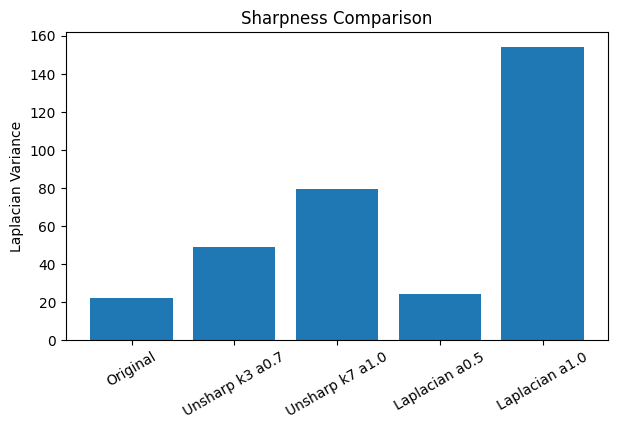

In [5]:
img = images[0]

u1 = unsharp(img,3,0.7)
u2 = unsharp(img,7,1.0)
l1 = laplacian_sharp(img,0.5)
l2 = laplacian_sharp(img,1.0)

lap_orig = cv2.Laplacian(img, cv2.CV_64F).var()
lap_u1 = cv2.Laplacian(u1, cv2.CV_64F).var()
lap_u2 = cv2.Laplacian(u2, cv2.CV_64F).var()
lap_l1 = cv2.Laplacian(l1, cv2.CV_64F).var()
lap_l2 = cv2.Laplacian(l2, cv2.CV_64F).var()

methods = [
    "Original",
    "Unsharp k3 a0.7",
    "Unsharp k7 a1.0",
    "Laplacian a0.5",
    "Laplacian a1.0"
]

values = [
    lap_orig,
    lap_u1,
    lap_u2,
    lap_l1,
    lap_l2
]

plt.figure(figsize=(7,4))
plt.bar(methods, values)

plt.ylabel("Laplacian Variance")
plt.title("Sharpness Comparison")

plt.xticks(rotation=30)
plt.show()

## Report Evidence Generation

In [9]:
REPORT_DIR = "../results/report_evidence/sharpen"
os.makedirs(REPORT_DIR, exist_ok=True)

def enhance(img):
    return unsharp(img,7,1.0)   

def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

for img, nm in zip(images, names):

    sharp = enhance(img)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(sharp, cmap="gray")
    plt.title("Sharpened (Unsharp k7 a1.0)")
    plt.axis("off")

    plt.suptitle(nm)

    save_path = os.path.join(
        REPORT_DIR,
        nm.replace(".jpg","")+"_before_after.png"
    )

    save_fig(save_path)

print("Saved before/after images")


csv_path = os.path.join(REPORT_DIR,"sharpen_metrics.csv")

with open(csv_path,"w",newline="") as f:

    writer = csv.writer(f)

    writer.writerow([
        "frame",
        "lap_before",
        "lap_after"
    ])

    for img,nm in zip(images,names):

        sharp = enhance(img)

        writer.writerow([
            nm,
            float(cv2.Laplacian(img,cv2.CV_64F).var()),
            float(cv2.Laplacian(sharp,cv2.CV_64F).var())
        ])

print("Saved metrics CSV:", csv_path)

Saved before/after images
Saved metrics CSV: ../results/report_evidence/sharpen\sharpen_metrics.csv
